# FGTV emissions charts (smoothed with HP filter)

Two charts from `decomposed_ssp_output.csv`, both filtered with the same Hodrick-Prescott smoother used in the R post-processing pipeline (anchored to the first observed year, non-negative).

1. **FGTV emissions by component** — flaring + venting + fugitive (dtp) per strategy.
2. **FGTV emissions by gas** — CO2 + CH4 + N2O per strategy, replicating the CCD "emissions by gas" stack.

Strategy mapping:
- `6003` BAU
- `6004` Unconditional NDC (ZRF)
- `6005` Conditional NDC


In [26]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.filters.hp_filter import hpfilter

# Latest run by default (override RUN_DIR below to pin a specific run)
RUNS_ROOT = Path('/Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output')
RUN_DIR = sorted(RUNS_ROOT.glob('sisepuede_results_sisepuede_run_*'))[-1]
print('Run dir:', RUN_DIR.name)

df = pd.read_csv(RUN_DIR / 'decomposed_ssp_output.csv')
att = pd.read_csv(RUN_DIR / 'ATTRIBUTE_PRIMARY.csv')
df = df.merge(att[['primary_id','strategy_id']], on='primary_id')
df['year'] = df['time_period'] + 2015
df = df[df.strategy_id != 0].copy()   # drop BASE
print('strategies:', sorted(df.strategy_id.unique()), '| years:', df.year.min(), '->', df.year.max())

STRATEGY_NAMES = {6003: 'BAU', 6004: 'Unconditional NDC (ZRF)', 6005: 'Conditional NDC'}
STRATEGY_ORDER = [6003, 6004, 6005]
LAMBDA_HP = 1600   # matches R post-processing default for Energy CH4/CO2


Run dir: sisepuede_results_sisepuede_run_2026-04-26T23;16;46.327653
strategies: [np.int64(6003), np.int64(6004), np.int64(6005)] | years: 2023 -> 2050


## HP filter helper

Hodrick-Prescott smoother, ported from `output_postprocessing/scr/data_prep_new_mapping.r::hp_filter_subsec`:

1. Apply `hpfilter` with `freq=lambda` to the per-strategy series.
2. Floor the trend at 0 (non-negative).
3. Shift so the smoothed series passes exactly through the first observed value (anchor).
4. Floor again, then re-pin the first point.


In [27]:
def hp_smooth(series: pd.Series, lambda_hp: float = LAMBDA_HP) -> pd.Series:
    """Anchored, non-negative HP trend matching the R hp_filter_subsec output."""
    s = series.astype(float).sort_index()
    if len(s) < 2:
        return s.copy()
    _, trend = hpfilter(s.values, lamb=lambda_hp)
    sm = np.maximum(trend, 0.0)
    shift = s.values[0] - sm[0]
    sm = np.maximum(sm + shift, 0.0)
    sm[0] = s.values[0]
    return pd.Series(sm, index=s.index, name=s.name)


def smooth_by_strategy(df_long: pd.DataFrame, value_cols, lambda_hp: float = LAMBDA_HP) -> pd.DataFrame:
    """Apply hp_smooth to each value_col within each strategy_id, indexed by year."""
    out = df_long.copy()
    for col in value_cols:
        for sid, sub in out.groupby('strategy_id'):
            s = sub.set_index('year')[col]
            sm = hp_smooth(s, lambda_hp = lambda_hp)
            out.loc[sub.index, col] = out.loc[sub.index, 'year'].map(sm)
    return out


## 1 — FGTV emissions by component (flaring + venting + dtp)


In [28]:
fgtv_cols = [c for c in df.columns if c.startswith('emission_co2e_') and '_fgtv_' in c and c != 'emission_co2e_subsector_total_fgtv']
flar_cols = [c for c in fgtv_cols if '_fgtv_flaring_' in c]
vent_cols = [c for c in fgtv_cols if '_fgtv_venting_' in c]
dtp_cols  = [c for c in fgtv_cols if '_fgtv_dtp_' in c]
print(f'flaring cols: {len(flar_cols)} | venting: {len(vent_cols)} | dtp: {len(dtp_cols)}')

comp = df[['strategy_id','year']].copy()
comp['flaring'] = df[flar_cols].sum(axis=1)
comp['venting'] = df[vent_cols].sum(axis=1)
comp['dtp']     = df[dtp_cols].sum(axis=1)
comp['total']   = comp[['flaring','venting','dtp']].sum(axis=1)

comp_sm = smooth_by_strategy(comp, ['flaring','venting','dtp','total'], lambda_hp = LAMBDA_HP)
comp_sm.head()


flaring cols: 12 | venting: 12 | dtp: 12


,strategy_id,year,flaring,venting,dtp,total
28,6003,2023,6.250542,15.663970,5.113488,27.028000
29,6003,2024,6.834939,15.364349,5.230421,27.429709
30,6003,2025,7.419118,15.061814,5.346646,27.827578
31,6003,2026,8.002102,14.750252,5.460539,28.212893
32,6003,2027,8.582517,14.422342,5.570061,28.574920


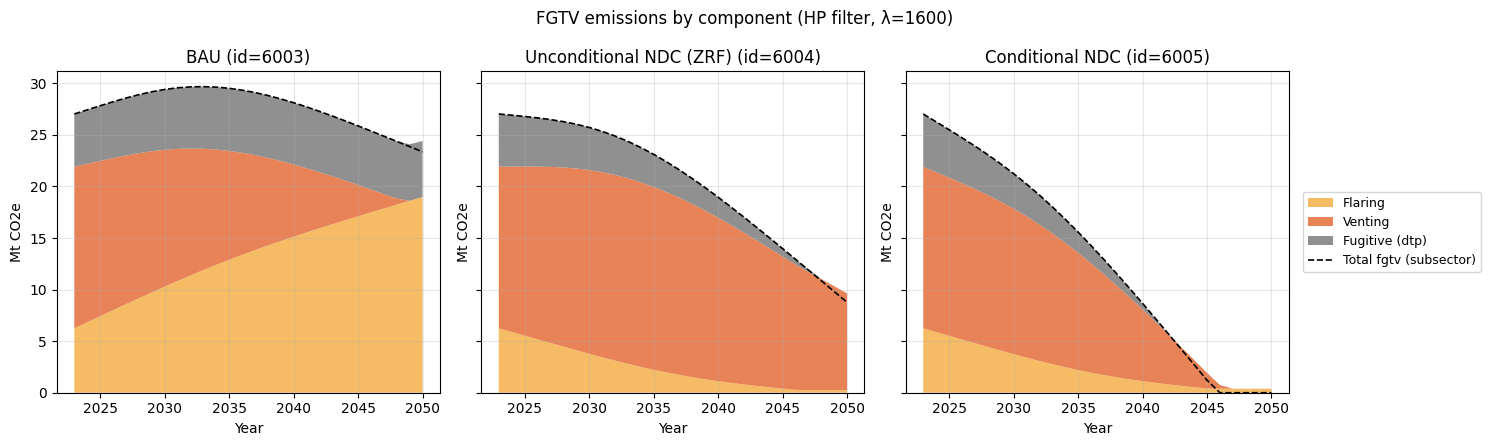

In [29]:
comp_colors = {'flaring': '#f5b04a', 'venting': '#e36d3a', 'dtp': '#7d7d7d'}
strategies_all = [s for s in STRATEGY_ORDER if s in comp_sm.strategy_id.unique()]
fig, axes = plt.subplots(1, len(strategies_all), figsize=(5.0*len(strategies_all), 4.5), sharey=True)
if len(strategies_all) == 1: axes = [axes]
for ax, sid in zip(axes, strategies_all):
    sub = comp_sm[comp_sm.strategy_id == sid].set_index('year').sort_index()
    ax.stackplot(sub.index, sub['flaring'], sub['venting'], sub['dtp'],
                 labels=['Flaring','Venting','Fugitive (dtp)'],
                 colors=[comp_colors['flaring'], comp_colors['venting'], comp_colors['dtp']], alpha=0.85)
    ax.plot(sub.index, sub['total'], 'k--', lw=1.2, label='Total fgtv (subsector)')
    ax.set_title(f"{STRATEGY_NAMES.get(sid, sid)} (id={sid})")
    ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2e'); ax.grid(alpha=0.3)
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
fig.suptitle(f'FGTV emissions by component (HP filter, λ={LAMBDA_HP})')
plt.tight_layout(); plt.show()


## 2 — FGTV emissions by gas (CO2 + CH4 + N2O)

Same FGTV totals, but split by greenhouse gas (in CO2e). Replicates the CCD "emissions by gas" stacked area chart, scoped to FGTV only.


In [30]:
co2_cols = [c for c in fgtv_cols if c.startswith('emission_co2e_co2_fgtv_')]
ch4_cols = [c for c in fgtv_cols if c.startswith('emission_co2e_ch4_fgtv_')]
n2o_cols = [c for c in fgtv_cols if c.startswith('emission_co2e_n2o_fgtv_')]
print(f'CO2 cols: {len(co2_cols)} | CH4 cols: {len(ch4_cols)} | N2O cols: {len(n2o_cols)}')

gas = df[['strategy_id','year']].copy()
gas['CO2'] = df[co2_cols].sum(axis=1)
gas['CH4'] = df[ch4_cols].sum(axis=1)
gas['N2O + F-gases'] = df[n2o_cols].sum(axis=1)   # FGTV has no F-gases; column kept for visual parity with CCD chart
gas['total'] = gas[['CO2','CH4','N2O + F-gases']].sum(axis=1)

gas_sm = smooth_by_strategy(gas, ['CO2','CH4','N2O + F-gases','total'], lambda_hp = LAMBDA_HP)
gas_sm.head()


CO2 cols: 12 | CH4 cols: 12 | N2O cols: 12


,strategy_id,year,CO2,CH4,N2O + F-gases,total
28,6003,2023,7.804993,19.193919,0.029088,27.028000
29,6003,2024,8.412271,18.988508,0.028930,27.429709
30,6003,2025,9.019093,18.779700,0.028784,27.827578
31,6003,2026,9.623947,18.560287,0.028659,28.212893
32,6003,2027,10.224774,18.321585,0.028561,28.574920


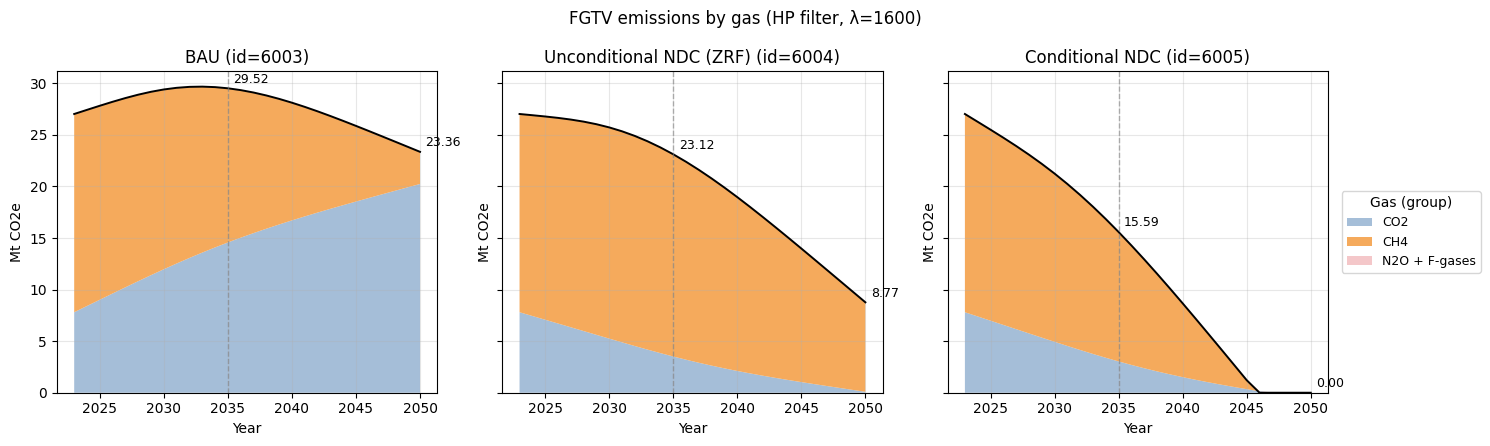

In [31]:
gas_colors = {'CO2': '#9bb7d4', 'CH4': '#f4a14a', 'N2O + F-gases': '#f3c1c4'}
fig, axes = plt.subplots(1, len(strategies_all), figsize=(5.0*len(strategies_all), 4.5), sharey=True)
if len(strategies_all) == 1: axes = [axes]
anchor_year = 2035
for ax, sid in zip(axes, strategies_all):
    sub = gas_sm[gas_sm.strategy_id == sid].set_index('year').sort_index()
    ax.stackplot(sub.index, sub['CO2'], sub['CH4'], sub['N2O + F-gases'],
                 labels=['CO2','CH4','N2O + F-gases'],
                 colors=[gas_colors['CO2'], gas_colors['CH4'], gas_colors['N2O + F-gases']], alpha=0.9)
    ax.plot(sub.index, sub['total'], 'k-', lw=1.4)
    if anchor_year in sub.index:
        ax.axvline(anchor_year, color='gray', ls='--', lw=1, alpha=0.6)
        ax.annotate(f"{sub.loc[anchor_year,'total']:.2f}", xy=(anchor_year, sub.loc[anchor_year,'total']),
                    xytext=(4, 4), textcoords='offset points', fontsize=9)
    last_year = sub.index.max()
    ax.annotate(f"{sub.loc[last_year,'total']:.2f}", xy=(last_year, sub.loc[last_year,'total']),
                xytext=(4, 4), textcoords='offset points', fontsize=9)
    ax.set_title(f"{STRATEGY_NAMES.get(sid, sid)} (id={sid})")
    ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2e'); ax.grid(alpha=0.3)
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, title='Gas (group)')
fig.suptitle(f'FGTV emissions by gas (HP filter, λ={LAMBDA_HP})')
plt.tight_layout(); plt.show()


## Export for Tableau

Long-format CSV with the same schema used by the existing Tableau workbook: `year, strategy_id, strategy_name, chart, metric, facility_type, value, units`. Smoothed values are exported (HP filter applied).

- `chart='fgtv_components'`: metrics `flar_emis_mt_co2e`, `vent_ch4_mt_co2e`, `dtp_ch4_mt_co2e`, `total_fgtv_mt_co2e` (component metric names match the previous Tableau extract).
- `chart='fgtv_by_gas'`: metrics `fgtv_co2_mt_co2e`, `fgtv_ch4_mt_co2e`, `fgtv_n2o_fgases_mt_co2e`, `total_fgtv_mt_co2e`.

Saved to `ssp_modeling/tableau/data/oilgas_ccd_charts_libya.csv` (overwriting prior file).


In [32]:
rows = []

# Chart A: FGTV components (smoothed)
comp_metric_map = {
    'flaring': ('flar_emis_mt_co2e', 'Mt CO2e'),
    'venting': ('vent_ch4_mt_co2e',  'Mt CO2e'),
    'dtp':     ('dtp_ch4_mt_co2e',   'Mt CO2e'),
    'total':   ('total_fgtv_mt_co2e','Mt CO2e'),
}
for _, r in comp_sm.iterrows():
    sid = int(r['strategy_id'])
    for col, (metric, units) in comp_metric_map.items():
        rows.append({
            'year': int(r['year']),
            'strategy_id': sid,
            'strategy_name': STRATEGY_NAMES.get(sid, str(sid)),
            'chart': 'fgtv_components',
            'metric': metric,
            'facility_type': 'All',
            'value': float(r[col]),
            'units': units,
        })

# Chart B: FGTV by gas (smoothed)
gas_metric_map = {
    'CO2':            ('fgtv_co2_mt_co2e',         'Mt CO2e'),
    'CH4':            ('fgtv_ch4_mt_co2e',         'Mt CO2e'),
    'N2O + F-gases':  ('fgtv_n2o_fgases_mt_co2e',  'Mt CO2e'),
    'total':          ('total_fgtv_mt_co2e',       'Mt CO2e'),
}
for _, r in gas_sm.iterrows():
    sid = int(r['strategy_id'])
    for col, (metric, units) in gas_metric_map.items():
        rows.append({
            'year': int(r['year']),
            'strategy_id': sid,
            'strategy_name': STRATEGY_NAMES.get(sid, str(sid)),
            'chart': 'fgtv_by_gas',
            'metric': metric,
            'facility_type': 'All',
            'value': float(r[col]),
            'units': units,
        })

tab = pd.DataFrame(rows, columns=['year','strategy_id','strategy_name','chart','metric','facility_type','value','units'])
out_path = Path('/Users/fabianfuentes/git/ssp_libya/ssp_modeling/tableau/data/oilgas_ccd_charts_libya.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
tab.to_csv(out_path, index=False)
print(f'Wrote {len(tab)} rows to {out_path}')
print('chart values :', sorted(tab.chart.unique()))
print('metric values:', sorted(tab.metric.unique()))
tab.head()


Wrote 672 rows to /Users/fabianfuentes/git/ssp_libya/ssp_modeling/tableau/data/oilgas_ccd_charts_libya.csv
chart values : ['fgtv_by_gas', 'fgtv_components']
metric values: ['dtp_ch4_mt_co2e', 'fgtv_ch4_mt_co2e', 'fgtv_co2_mt_co2e', 'fgtv_n2o_fgases_mt_co2e', 'flar_emis_mt_co2e', 'total_fgtv_mt_co2e', 'vent_ch4_mt_co2e']


,year,strategy_id,strategy_name,chart,metric,facility_type,value,units
0,2023,6003,BAU,fgtv_components,flar_emis_mt_co2e,All,6.250542,Mt CO2e
1,2023,6003,BAU,fgtv_components,vent_ch4_mt_co2e,All,15.663970,Mt CO2e
2,2023,6003,BAU,fgtv_components,dtp_ch4_mt_co2e,All,5.113488,Mt CO2e
3,2023,6003,BAU,fgtv_components,total_fgtv_mt_co2e,All,27.028000,Mt CO2e
4,2024,6003,BAU,fgtv_components,flar_emis_mt_co2e,All,6.834939,Mt CO2e


## Notes

- `LAMBDA_HP=1600` matches the R post-processing default used for Energy CH4/CO2 series. Use 600 for noisier series, 100 for almost-no-smoothing.
- The first observed year (2023) is anchored exactly to the model output. Smoothing only affects later years.
- The dashed black line on chart 1 is the FGTV subsector total (sanity check: should equal the stacked sum).
